# Goal

Confirm that gradient descent for my model is correct using gradient checking. To carry out gradient checking you need the following:

1. f_x(x, theta) - function to make prediction using concatenated parameters
2. J(x, y, theta) - function to get cost of using concatenated parameters
3. backprop(x, y) - function to return concatenated derivatives
4. grad_check(x, y) - function to get dtheta_approx
5. analyze_grad_descent(x,y) - function to analyze results of gradient check

In [32]:
# Imports
import numpy as np
import numpy.typing as npt
from sklearn.model_selection import train_test_split
rng = np.random.default_rng(seed=69)
from model_helpers import precision_recall, accuracy_score, win_prediction_accuracy
import matplotlib.pyplot as plt

In [4]:
# Import data and splitting data into train / cross-validation / test sets
X = np.load("data/duplicate_players_batch_6_2026-06-01 18:30:48.366255.npy")
Y = np.load("data/duplicate_results_batch_6_2026-06-01 18:30:48.366274.npy")
X_train, X_mid, Y_train, Y_mid = train_test_split(X, Y, test_size=0.14, random_state=69)
X_cv, X_test, Y_cv, Y_test = train_test_split(X_mid, Y_mid, test_size=0.5, random_state=69)

X_grad_check = X_train[:50]
Y_grad_check = Y_train[:50]

# Scale features
mean = np.mean(X_grad_check, axis=(0,1), keepdims=True)
std = np.std(X_grad_check, axis=(0,1), keepdims=True)
std = np.where(std == 0, 1.0, std)

X_grad_check_scaled = (X_grad_check - mean) / std
print(X_grad_check_scaled.shape)
print(Y_grad_check.shape)

mean = np.mean(X_train, axis=(0,1), keepdims=True)
std = np.std(X_train, axis=(0,1), keepdims=True)
std = np.where(std == 0, 1.0, std)

X_train_scaled = (X_train - mean) / std
X_cv_scaled = (X_cv - mean) / std
X_test_scaled = (X_test - mean) / std

(50, 22, 9)
(50, 121, 1)


In [5]:
w_1_end_index = 27
b_1_end_index = 30
w_2_end_index = 33
b_2_end_index = 34
w_3_end_index = 2696
total_params = 2817

In [6]:
def concatenated_to_params(theta: npt.NDArray):
    f""" 
    Converts concatenated array to params
    
    Args:
        theta (ndarray): a ({total_params},) array concatenated parameters
        
    Returns:
        w_1 (ndarray): a (3,9) array with weights of first layer
        b_1 (ndarray): a (3,1) array with bias of first layer
        w_2 (ndarray): a (1,3) array with weights of second layer
        b_2 (scalar): bias of second layer
        w_3 (ndarray): a (121, 22) array with weights of third layer
        b_3 (ndarray): a (121, 1) array with bias of third layer
    """
    w_1 = np.array(theta[0:w_1_end_index]).reshape((3,9))
    b_1 = np.array(theta[w_1_end_index:b_1_end_index]).reshape((3,1))
    w_2 = np.array(theta[b_1_end_index:w_2_end_index]).reshape((1,3))
    b_2 = theta[w_2_end_index]
    w_3 = np.array(theta[b_2_end_index:w_3_end_index]).reshape((121,22))
    b_3 = np.array(theta[w_3_end_index:]).reshape((121, 1))
    
    return (w_1, b_1, w_2, b_2, w_3, b_3)

def params_to_condensed(
    w_1: npt.NDArray,
    b_1: npt.NDArray,
    w_2: npt.NDArray,
    b_2: float,
    w_3: npt.NDArray,
    b_3: npt.NDArray
):
    f"""
    Function to condense model parameters into a single vector
    
    Args:
        w_1 (ndarray) - (3, 9) array with weights of first layer of network
        b_1 (ndarray) - (3, 1) bias for first layer
        w_2 (ndarray) - (1,3) array with weights of second layer of network
        b_2 (scalar) - bias of second network
        w_3 (ndarray) - (121, 22) array with weights of team portion of network
        b_3 (ndarray) - (121, 1) array with bias of team portion of network
        
    Returns:
        theta (ndarray) - ({total_params},) condensed vector
    """
    theta = []
    theta.extend(w_1.flatten(order='C'))
    theta.extend(b_1.flatten(order='C'))
    theta.extend(w_2.flatten(order='C'))
    theta.append(np.float64(b_2))
    theta.extend(w_3.flatten(order='C'))
    theta.extend(b_3.flatten(order='C'))
    return np.array(theta)

In [7]:
def f_x(
    x_i: npt.NDArray,
    theta: npt.NDArray
):
    """ 
    Non-vectorized forward prop
    
    Args:
        x_i (ndarray): a (22, 9) array with training features
        theta (ndarray): a concatenated array with training parameters
        
    Returns:
        y_pred_i (ndarray): a (121, 1) array with predictions from model
        a_2_i (ndarray): cached a_2_i value
        z_2_i (ndarray): cached z_2_i value
        a_1_i (ndarray): cached a_1_i value
        z_1_i (ndarray): cached z_1_i value
    """
    w_1, b_1, w_2, b_2, w_3, b_3 = concatenated_to_params(theta=theta)
    
    z_1_i = np.matmul(x_i, w_1.T) + b_1.T
    a_1_i = np.maximum(0, z_1_i)
    z_2_i = np.matmul(a_1_i,w_2.T) + b_2
    a_2_i = np.maximum(0, z_2_i)
    z_3_i = np.matmul(w_3, a_2_i) + b_3
    shifted_logits = z_3_i - np.max(z_3_i, axis=0, keepdims=True)
    e_zi = np.exp(shifted_logits)
    y_pred_i = e_zi / np.sum(e_zi, axis=0, keepdims=True)
    return (y_pred_i, a_2_i, z_2_i, a_1_i, z_1_i)

x_i_example = np.ones((22,9))
# theta = np.array(list(range(total_params)))
theta = np.zeros((total_params,))
print(f_x(x_i=x_i_example, theta=theta)[0])

[[0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00

In [8]:
# X_example = np.array([
#         np.ones((22,9))
#     ])
# Y_pred, _, _ = predict(
#     X=X_example,
#     theta=np.zeros((2793,))
# )
# print(Y_pred)

In [9]:
def J(
    X: npt.NDArray,
    Y: npt.NDArray,
    theta: npt.NDArray
):
    f""" 
    Calculates cost of current parameters
    
    Args:
        X (ndarray): a (m, 22, 9) array with m training examples
        Y (ndarray): a (m, 121, 1) array with target outputs of training examples
        theta (ndarray): a ({total_params},) array with concatenated parameters
        
    Returns:
        cost (scalar): cost of current parameters
    """
    m = X.shape[0]
    cost = 0
    
    for i in range(m):
        x_i = X[i]
        y_i = Y[i]
        y_pred_i, _, _, _, _ = f_x(
            x_i=x_i,
            theta=theta
        )
        
        cost += np.sum(np.where(y_i == 1, -np.log(y_pred_i + 1e-15), 0))
        
    return cost / m
    
print(J(
    X=X_grad_check_scaled,
    Y = Y_grad_check,
    theta = rng.random((total_params,))
))

17.733609219075344


In [10]:
def backprop(
    X: npt.NDArray,
    Y: npt.NDArray,
    theta: npt.NDArray
):
    f""" 
    Get the derivative of weights and biases used by model
    
    Args:
        X (ndarray): a (m, 22, 9) array with m training examples
        Y (ndarray): a (m, 121, 1) array with target outputs
        theta (ndarray): a ({total_params},) array with concatenated parameters
        
    Returns:
        dtheta (ndarray): a ({total_params},) array with concatenated parameters
    """
    m = X.shape[0]
    
    _, _, w_2, _, w_3, _ = concatenated_to_params(theta=theta)
    
    dw_1 = np.zeros((3, 9))
    db_1 = np.zeros((3, 1))
    dw_2 = np.zeros((1, 3))
    db_2 = 0
    dw_3 = np.zeros((121, 22))
    db_3 = np.zeros((121, 1))
    
    for i in range(m):
        x_i = X[i]
        y_i = Y[i]
        y_pred_i, a_2_i, z_2_i, a_1_i, z_1_i = f_x(
            x_i=x_i, theta=theta
        )
        
        dz_3_i = y_pred_i - y_i
        dw_3 += np.matmul(dz_3_i, a_2_i.T)
        db_3 += dz_3_i
        da_2_i = np.matmul(w_3.T, dz_3_i)
        dz_2_i = np.where(z_2_i < 0, 0, da_2_i)
        dw_2 += np.matmul(dz_2_i.T, a_1_i)
        db_2 += np.sum(dz_2_i, axis=0)[0]
        da_1_i = np.matmul(dz_2_i, w_2)
        dz_1_i = np.where(z_1_i < 0, 0, da_1_i)
        dw_1 += np.matmul(dz_1_i.T, x_i)
        db_1 += np.sum(dz_1_i.T, axis=1).reshape(3, 1)
        
    
    dw_1 /= m
    db_1 /= m
    dw_2 /= m
    db_2 /= m
    dw_3 /= m
    db_3 /= m
    
    return params_to_condensed(
        w_1=dw_1,
        b_1 = db_1,
        w_2=dw_2,
        b_2=db_2,
        w_3=dw_3,
        b_3=db_3
    )
    
print(backprop(
    X= X_grad_check,
    Y= Y_grad_check,
    theta = rng.random((total_params,))
))

[3.47346522e+001 5.23831277e-001 5.11749283e-001 ... 2.00026375e-002
 7.77011440e-225 4.64155225e-181]


In [11]:
def grad_check(
    X: npt.NDArray,
    Y: npt.NDArray,
    theta: npt.NDArray
):
    """ 
    Returns dtheta_approx and dtheta together with similarity of the 2 concatenated arrays
    
    Args:
        X (ndarray): a (m, 22, 9) array with m training examples
        Y (ndarray): a (m, 121, 1) array with m target labels
        theta (ndarray): a (2793,) array with concatenated parameters
        
    Return:
        similarity (scalar): similarity of dtheta and dtheta approx
        dtheta (ndarray): a (2793,) array with concatenated derivatives from backprop
        dtheta_approx (ndarray): a (2793,) array with approximated derivatives
    """
    num_params = theta.shape[0]
    dtheta = backprop(
        X=X,
        Y=Y,
        theta=theta
    )
    dtheta_approx = np.zeros((total_params,))
    epsilon = 1e-7
    
    for i in range(num_params):
        if i % 500 == 0 or i == num_params - 1:
            print(f"Getting {i}th value in dtheta approx")
            
        theta_right = theta.copy()
        theta_left = theta.copy()
        theta_right[i] += epsilon
        theta_left[i] -= epsilon
        J_theta_right = J(X=X,Y=Y,theta=theta_right)
        J_theta_left = J(X=X,Y=Y,theta=theta_left)
        d_theta_approx_i = (J_theta_right - J_theta_left) / (2 * epsilon)
        dtheta_approx[i] = d_theta_approx_i
        
    print(dtheta) 
    print(dtheta_approx)
    
    distance = np.linalg.norm(dtheta_approx - dtheta)
    similarity_check = distance / (np.linalg.norm(dtheta_approx) + np.linalg.norm(dtheta))
    
    # Interpreting results
    print(f"The difference between dtheta_approx and dtheta is {similarity_check}")
    return (similarity_check, dtheta, dtheta_approx)

In [12]:
def analyze_grad_check(
    X: npt.NDArray,
    Y: npt.NDArray,
    theta: npt.NDArray,
):
    """ 
    Gets approximate dtheta and compares it with dtheta gotten with implementation of gradient descent
    
    Args:
        X (ndarray): a (m, 2, 1) array with m training examples
        Y (ndarray): a (m,) array with labels for each training example
        theta (ndarray): condensed parameters for network
        calculate_gradients: function to return dtheta for parameters
    """
    _, dtheta, dtheta_approx = grad_check(
        X=X,
        Y=Y,
        theta=theta,
    )
    
    num_params = theta.shape[0]
    
    w_1_problem = 0
    b_1_problem = 0
    w_2_problem = 0
    b_2_problem = 0
    w_3_problem = 0
    b_3_problem = 0
    
    # Getting total problem for each category
    for i in range(num_params):
        dtheta_value = dtheta[i]
        dtheta_approx_value = dtheta_approx[i]
        difference = (dtheta_approx_value - dtheta_value) ** 2
        
        if 0 <= i < w_1_end_index:
            w_1_problem += difference / (np.abs(dtheta_approx_value) ** 2  + np.abs(dtheta_value) ** 2)
        elif w_1_end_index <= i < b_1_end_index:
            b_1_problem += difference / (np.abs(dtheta_approx_value) ** 2  + np.abs(dtheta_value) ** 2)
        elif b_1_end_index <= i < w_2_end_index:
            w_2_problem += difference / (np.abs(dtheta_approx_value) ** 2  + np.abs(dtheta_value) ** 2)
        elif w_2_end_index <= i < b_2_end_index:
            b_2_problem += difference / (np.abs(dtheta_approx_value) ** 2  + np.abs(dtheta_value) ** 2)
        elif b_2_end_index <= i < w_3_end_index:
            w_3_problem += difference / (np.abs(dtheta_approx_value) ** 2  + np.abs(dtheta_value) ** 2)
        elif w_3_end_index <= i < total_params:
            b_3_problem += difference / (np.abs(dtheta_approx_value) ** 2  + np.abs(dtheta_value) ** 2)
        else:
            print(f"Don't know how to intepret {i}")
            
    print(f"Problem for w_1 is {w_1_problem}")
    print(f"Problem for b_1 is {b_1_problem}")
    print(f"Problem for w_2 is {w_2_problem}")
    print(f"Problem for b_2 is {b_2_problem}")
    print(f"Problem for w_3 is {w_3_problem}")
    print(f"Problem for b_3 is {b_3_problem}")
    
    largest = np.argmax([w_1_problem, b_1_problem, w_2_problem, b_2_problem, w_3_problem, b_3_problem])
    
    if largest == 0:
        start_range = 0
        end_range = w_1_end_index
        problem_param = "w_1"
    elif largest == 1:
        start_range = w_1_end_index
        end_range = b_1_end_index
        problem_param = "b_1"
    elif largest == 2:
        start_range = b_1_end_index
        end_range = w_2_end_index
        problem_param = "w_2"
    elif largest == 3:
        start_range = w_2_end_index
        end_range = b_2_end_index
        problem_param = "b_2"
    elif largest == 4:
        start_range = b_2_end_index
        end_range = b_2_end_index + 10
        problem_param = "w_3"
    else:
        start_range = w_3_end_index
        end_range = w_3_end_index + 10
        problem_param = "b_3"
    
    for idx in range(start_range, end_range):
        dtheta_value = dtheta[idx]
        dtheta_approx_value = dtheta_approx[idx]
        
        print(f"Element index {idx} in {problem_param} has dtheta of {dtheta_value} and dtheta_approx of {dtheta_approx_value}")

In [13]:
analyze_grad_check(
    X=X_grad_check_scaled,
    Y=Y_grad_check,
    theta=rng.random(total_params)
)

Getting 0th value in dtheta approx
Getting 500th value in dtheta approx
Getting 1000th value in dtheta approx
Getting 1500th value in dtheta approx
Getting 2000th value in dtheta approx
Getting 2500th value in dtheta approx
Getting 2816th value in dtheta approx
[ 0.64145345  0.16859503 -0.17464869 ...  0.00125775  0.01074897
  0.00079456]
[ 0.64145343  0.16859482 -0.17464861 ...  0.00125774  0.01074898
  0.00079457]
The difference between dtheta_approx and dtheta is 1.4386579015050228e-07
Problem for w_1 is 1.3871550289190987e-11
Problem for b_1 is 6.937766844059464e-14
Problem for w_2 is 1.0126895961240837e-13
Problem for b_2 is 4.496583928320512e-14
Problem for w_3 is 4.350198574412211e-06
Problem for b_3 is 5.285563557500639e-08
Element index 34 in w_3 has dtheta of -0.0061006936251887574 and dtheta_approx of -0.006100684402099432
Element index 35 in w_3 has dtheta of -0.013117449296952905 and dtheta_approx of -0.013117453789845968
Element index 36 in w_3 has dtheta of -0.0757387703

In [14]:
def gradient_descent(
    X: npt.NDArray,
    Y: npt.NDArray,
    theta: npt.NDArray,
    alpha: float,
    num_iters: int,
    J_n: int = 100
):
    f""" 
    Train model that's using new architecture above
    
    Args:
        X (ndarray): a (m, 22, 9) array with m training examples
        Y (ndarray): a (m, 121, 1) array with m target labels
        theta (ndarray): a ({total_params},) array with concatenated params
        alpha (scalar): learning rate
        num_items (scalar): number of times to run gradient descent
        J_n (scalar): intervals to store J values in
    """
    Js = []
        
    for epoch in range(num_iters):
        dtheta = backprop(
            X=X,
            Y=Y,
            theta=theta
        )
        w_1, b_1, w_2, b_2, w_3, b_3 = concatenated_to_params(theta=theta)
        dw_1, db_1, dw_2, db_2, dw_3, db_3 = concatenated_to_params(theta=dtheta)
        
        # Update weights
        w_1 = w_1 - (alpha * dw_1)
        w_2 = w_2 - (alpha * dw_2)
        w_3 = w_3 - (alpha * dw_3)
        b_1 = b_1 - (alpha * db_1)
        b_2 = b_2 - (alpha * db_2)
        b_3 = b_2 - (alpha * db_3)
        
        theta = params_to_condensed(
            w_1=w_1,
            b_1 = b_1,
            w_2=w_2,
            b_2=b_2,
            w_3=w_3,
            b_3=b_3
        )
        cost = J(X=X,Y=Y,theta=theta)
        
        # Print result
        print(f"Cost at epoch {epoch}/{num_iters} = {cost}")
        
        if epoch % J_n == 0 or epoch == num_iters - 1:
            Js.append((epoch, cost))
        
    w_1, b_1, w_2, b_2, w_3, b_3 = concatenated_to_params(theta=theta)
    return (w_1, b_1, w_2, b_2, w_3, b_3, Js)
    

Cost at epoch 0/1000 = 4.867510766264028
Cost at epoch 1/1000 = 4.8604261367785115
Cost at epoch 2/1000 = 4.853446387262513
Cost at epoch 3/1000 = 4.846563500493159
Cost at epoch 4/1000 = 4.839769266778892
Cost at epoch 5/1000 = 4.833056449634037
Cost at epoch 6/1000 = 4.826417719115364
Cost at epoch 7/1000 = 4.819846225247796
Cost at epoch 8/1000 = 4.81333471315696
Cost at epoch 9/1000 = 4.806876740517977
Cost at epoch 10/1000 = 4.800465934094377
Cost at epoch 11/1000 = 4.794095528991645
Cost at epoch 12/1000 = 4.787759046439496
Cost at epoch 13/1000 = 4.781450381287422
Cost at epoch 14/1000 = 4.775163053142736
Cost at epoch 15/1000 = 4.768890590753611
Cost at epoch 16/1000 = 4.762628450293083
Cost at epoch 17/1000 = 4.756370581870802
Cost at epoch 18/1000 = 4.750111175825986
Cost at epoch 19/1000 = 4.7438437155617486
Cost at epoch 20/1000 = 4.737562489449169
Cost at epoch 21/1000 = 4.731262451431744
Cost at epoch 22/1000 = 4.724888099566129
Cost at epoch 23/1000 = 4.7183232637126675


Text(0.5, 1.0, 'Training cost vs Epochs')

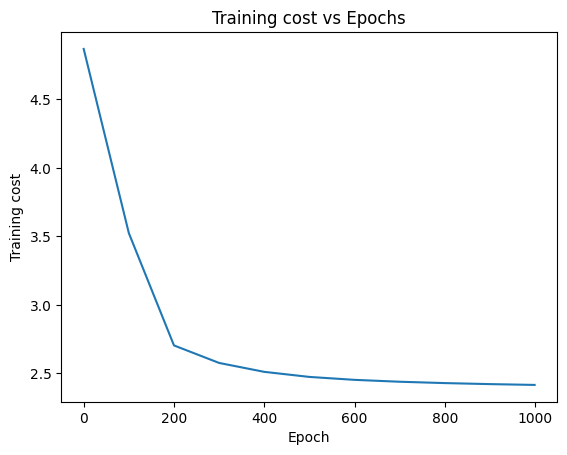

In [22]:
init_w_1 = rng.random((3,9)) * np.sqrt(2 / 9)
init_b_1 = np.zeros((3,1))
init_w_2 = rng.random((1,3)) * np.sqrt(2 / 3)
init_b_2 = 0
init_w_3 = rng.random((121, 22)) * np.sqrt(1 / 22)
init_b_3 = np.zeros((121, 1))
init_theta = params_to_condensed(
    w_1=init_w_1,
    b_1 = init_b_1,
    w_2=init_w_2,
    b_2=init_b_2,
    w_3=init_w_3,
    b_3=init_b_3
)

new_w_1, new_b_1, new_w_2, new_b_2, new_w_3, new_b_3, J_train_s = gradient_descent(
    X=X_train_scaled,
    Y=Y_train,
    theta=init_theta,
    alpha=0.01,
    num_iters=1000,
    J_n=100
)

epochs = [x[0] for x in J_train_s]
Js = [y[1] for y in J_train_s]

print(f"Training cost {J_train_s[-1][1]}")
plt.plot(epochs, Js)
plt.xlabel("Epoch")
plt.ylabel("Training cost")
plt.title(f"Training cost vs Epochs")

In [33]:
# Seeing if model is still suffering from high bias
new_theta = params_to_condensed(w_1=new_w_1, b_1=new_b_1, w_2=new_w_2, b_2=new_b_2, w_3=new_w_3, b_3=new_b_3)
train_set_pred = []
for x_i in X_train_scaled:
    y_pred_i, _, _, _, _ = f_x(x_i=x_i, theta=new_theta)
    train_set_pred.append(y_pred_i)
    
train_set_pred = np.array(train_set_pred)

cv_set_pred = []
for x_i in X_cv_scaled:
    y_pred_i, _, _, _, _ = f_x(x_i=x_i, theta=new_theta)
    cv_set_pred.append(y_pred_i)
    
cv_set_pred = np.array(cv_set_pred)

training_set_accuracy = accuracy_score(train_set_pred, Y_train)
cv_set_accuracy = accuracy_score(cv_set_pred, Y_cv)
training_set_win_pred_accuracy = win_prediction_accuracy(y_pred=train_set_pred, y_label=Y_train)
cv_set_win_pred_accuracy = win_prediction_accuracy(y_pred=cv_set_pred, y_label=Y_cv)

print(f"Benchmark Score Accuracy: 0.18")
print(f"Benchmark Win Accuracy  : 0.7542")
print(f"Training Score Accuracy : {training_set_accuracy}")
print(f"Training Win Accuracy   : {training_set_win_pred_accuracy}")
print(f"CV Set Score Accuracy   : {cv_set_accuracy}")
print(f"CV Set Win Accuracy     : {cv_set_win_pred_accuracy}")

Benchmark Score Accuracy: 0.18
Benchmark Win Accuracy  : 0.7542
Training Score Accuracy : 0.16957605985037408
Training Win Accuracy   : 0.5178719866999169
CV Set Score Accuracy   : 0.10204081632653061
CV Set Win Accuracy     : 0.45918367346938777


In [34]:
# Seeing precision recall of model
precision_recall(y_pred=cv_set_pred, y_label=Y_cv)

    Precision and recall
 2-0   TP:1  FP:14  FN:12: Prec:0.0667  Rec:0.0769  F1:56.0000  #Pred: 15  Sample:13
 0-2   TP:3  FP:10  FN:10: Prec:0.2308  Rec:0.2308  F1:17.3333  #Pred: 13  Sample:13
 0-0   TP:1  FP:3  FN:11: Prec:0.2500  Rec:0.0833  F1:32.0000  #Pred: 4  Sample:12
 4-0   TP:0  FP:1  FN:11: Prec:0.0000  Rec:0.0000  F1:0.0000  #Pred: 1  Sample:11
 0-1   TP:0  FP:20  FN:10: Prec:0.0000  Rec:0.0000  F1:0.0000  #Pred: 20  Sample:10
 3-0   TP:3  FP:13  FN:6: Prec:0.1875  Rec:0.3333  F1:16.6667  #Pred: 16  Sample:9
 0-3   TP:2  FP:13  FN:6: Prec:0.1333  Rec:0.2500  F1:23.0000  #Pred: 15  Sample:8
 5-0   TP:0  FP:0  FN:5: Prec:0.0000  Rec:0.0000  F1:0.0000  #Pred: 0  Sample:5
 0-4   TP:0  FP:1  FN:5: Prec:0.0000  Rec:0.0000  F1:0.0000  #Pred: 1  Sample:5
 1-0   TP:0  FP:13  FN:5: Prec:0.0000  Rec:0.0000  F1:0.0000  #Pred: 13  Sample:5
 6-0   TP:0  FP:0  FN:2: Prec:0.0000  Rec:0.0000  F1:0.0000  #Pred: 0  Sample:2
 0-5   TP:0  FP:0  FN:2: Prec:0.0000  Rec:0.0000  F1:0.0000  #Pred: 